Imports and data loading (both CISO and NYISO)
CISO.head() and NYISO.head() — show the raw data
CISO.describe() — summary statistics
CISO.dtypes — confirm column types
Check for missing values and date range
Parse datetime, extract hour_of_day, dow, month
Average hourly price profile plot (the duck curve chart you made)
Histogram of prices with kde=True
Skewness and kurtosis printout
Daily average price over time (full time series)
Brief markdown cells between each section explaining what you observe

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.price_model import *
from src.optimization import *
from src.simulation import *

from pathlib import Path

DATA_DIR = Path("../data")

ciso = pd.read_csv(DATA_DIR / "prices_CISO.csv")
nyiso = pd.read_csv(DATA_DIR / "prices_NYIS.csv")

print(ciso.head())
print(nyiso.head())

                  hour  price_usd_mwh
0  2023-02-20 08:00:00       60.32304
1  2023-02-20 09:00:00       55.32406
2  2023-02-20 10:00:00       54.56625
3  2023-02-20 11:00:00       53.46376
4  2023-02-20 12:00:00       54.15153
                  hour  price_usd_mwh
0  2019-01-01 05:00:00          25.57
1  2019-01-01 06:00:00          22.20
2  2019-01-01 07:00:00          18.50
3  2019-01-01 08:00:00          18.32
4  2019-01-01 09:00:00          18.56


In [3]:
ciso.describe()

,price_usd_mwh
count,28144.000000
mean,41.620890
std,28.296911
min,-38.471220
25%,29.121405
50%,39.978605
75%,51.227430
max,1090.904500


In [4]:
nyiso.describe()

,price_usd_mwh
count,64991.000000
mean,47.578696
std,44.731817
min,5.770000
25%,24.740000
50%,34.710000
75%,54.540000
max,1058.270000


In [6]:
print(ciso.dtypes)
print(nyiso.dtypes)

hour              object
price_usd_mwh    float64
dtype: object
hour              object
price_usd_mwh    float64
dtype: object


In [7]:
ciso.isna()

,hour,price_usd_mwh
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
28139,False,False
28140,False,False
28141,False,False
28142,False,False


In [8]:
ciso["hour"] = pd.to_datetime(ciso["hour"])
ciso["hour_of_day"] = ciso["hour"].dt.hour
ciso["dow"] = ciso["hour"].dt.dayofweek
ciso["month"] = ciso["hour"].dt.month

nyiso["hour"] = pd.to_datetime(nyiso["hour"])
nyiso["hour_of_day"] = nyiso["hour"].dt.hour
nyiso["dow"] = nyiso["hour"].dt.dayofweek
nyiso["month"] = nyiso["hour"].dt.month

Now we examine the daily price profiles of both ISOs. As we can see, they appear drastically different, reflecting different storage methods and varying demands for different times of day. This would make any sort of naive, hour-based strategy highly ineffective for generalizing across ISOs.

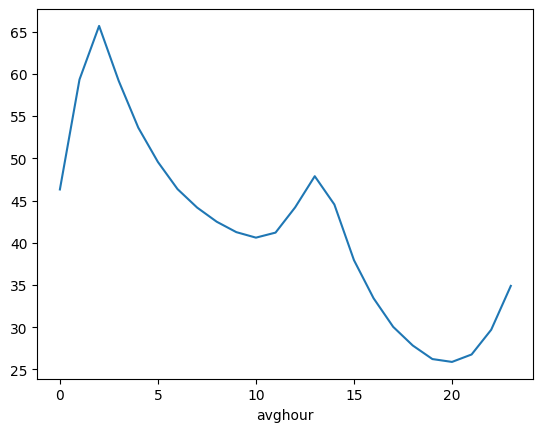

In [9]:
ciso["avghour"] = ciso["hour"].dt.hour
perhour = ciso.groupby("avghour")["price_usd_mwh"].mean()
perhour.plot()
plt.show()

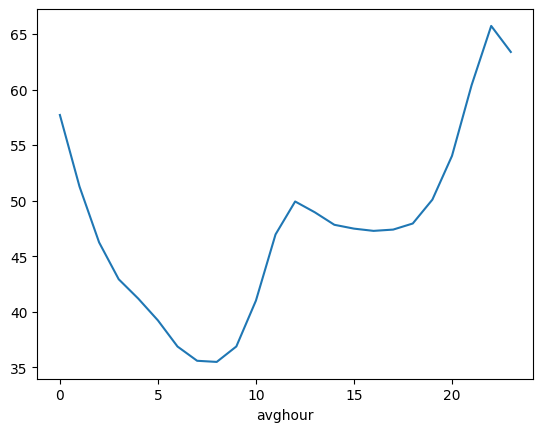

In [11]:
nyiso["avghour"] = nyiso["hour"].dt.hour
perhour = nyiso.groupby("avghour")["price_usd_mwh"].mean()
perhour.plot()
plt.show()

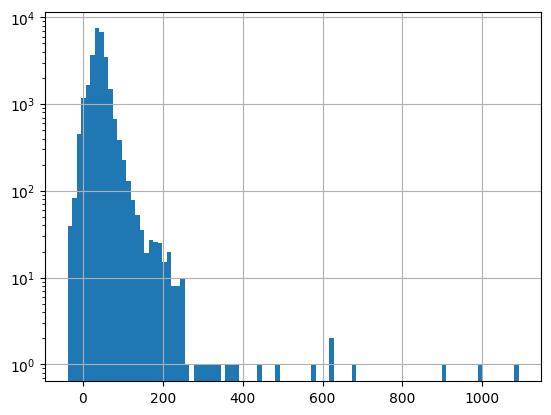

In [12]:
ciso["price_usd_mwh"].hist(bins=100)
plt.yscale("log")
plt.show()

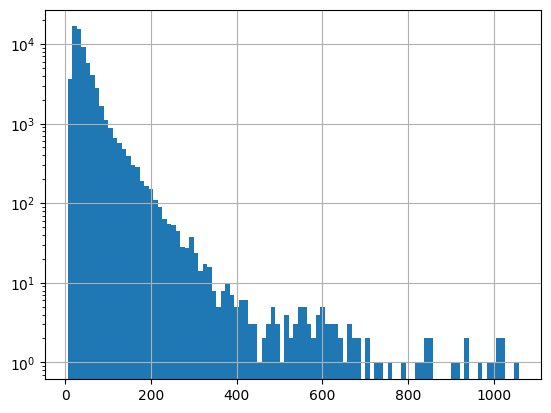

In [13]:
nyiso["price_usd_mwh"].hist(bins=100)
plt.yscale("log")
plt.show()

<Axes: xlabel='price_usd_mwh', ylabel='Count'>

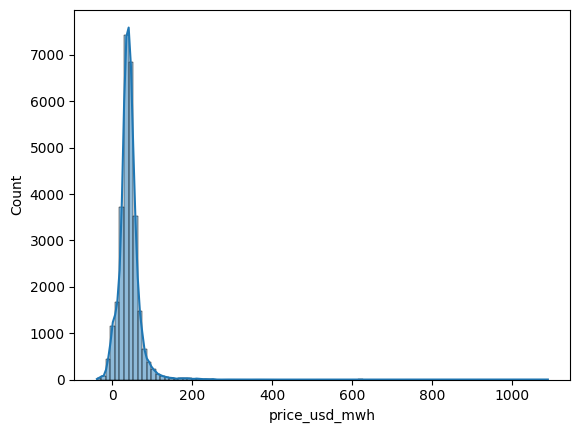

In [17]:
sns.histplot(data=ciso, x="price_usd_mwh", bins=100, kde=True)

<Axes: xlabel='price_usd_mwh', ylabel='Count'>

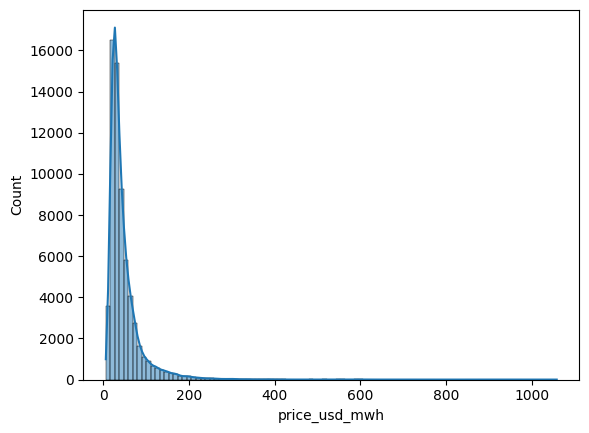

In [18]:
sns.histplot(data = nyiso, x="price_usd_mwh", bins =100, kde=True)

In [24]:
print(f"CISO skew : {ciso['price_usd_mwh'].skew():.2f}")
print(f"NYISO skew : {nyiso['price_usd_mwh'].skew():.2f}")
print(f"CISO kurtosis : {ciso['price_usd_mwh'].kurt():.2f}")
print(f"NYISO kurtosis : {nyiso['price_usd_mwh'].kurt():.2f}")

CISO skew : 7.25
NYISO skew : 6.17
CISO kurtosis : 183.20
NYISO kurtosis : 76.76


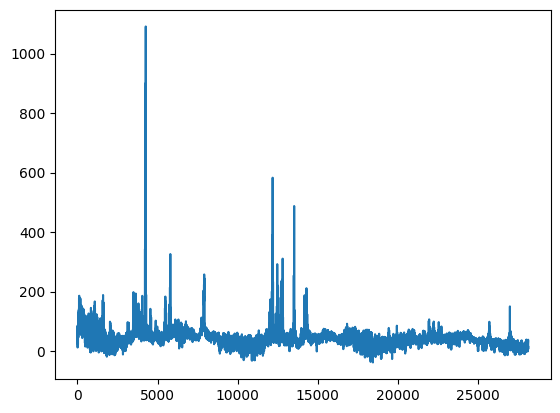

In [26]:
ciso["price_usd_mwh"].plot()
plt.show()

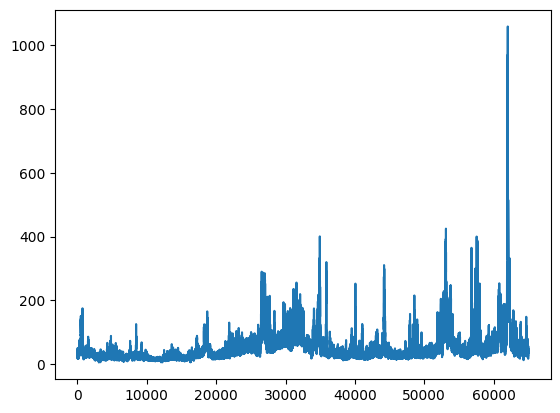

In [27]:
nyiso["price_usd_mwh"].plot()
plt.show()